# OpenCV를 활용한 영상정보 전처리(5)

# 이미지 변경

# 이미지 이동, 회전, 크기 재조정, 대칭 시키기를 한다.

In [1]:
# 필요한 패키지 읽어오기

import cv2
from google.colab.patches import cv2_imshow
import numpy as np

In [ ]:
# OpenCV 버전 확인

print("OpenCV version:")
print(cv2.__version__)

OpenCV version:
4.6.0


In [2]:
# 내 구글 드라이버에 연동

from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# 이미지를 읽어 온다.

img = cv2.imread('gdrive/My Drive/CV/Basic Vision Skills/images/rear_garden.PNG', cv2.IMREAD_COLOR)
print(img.shape)                                   # 형상 - (496, 819, 3)
print("width: {} pixels".format(img.shape[1]))     # 넓이
print("height: {} pixels".format(img.shape[0]))    # 높이
print("channels: {}".format(img.shape[2]))         # 채널

(496, 819, 3)
width: 819 pixels
height: 496 pixels
channels: 3


width: 819 pixels
height: 496 pixels


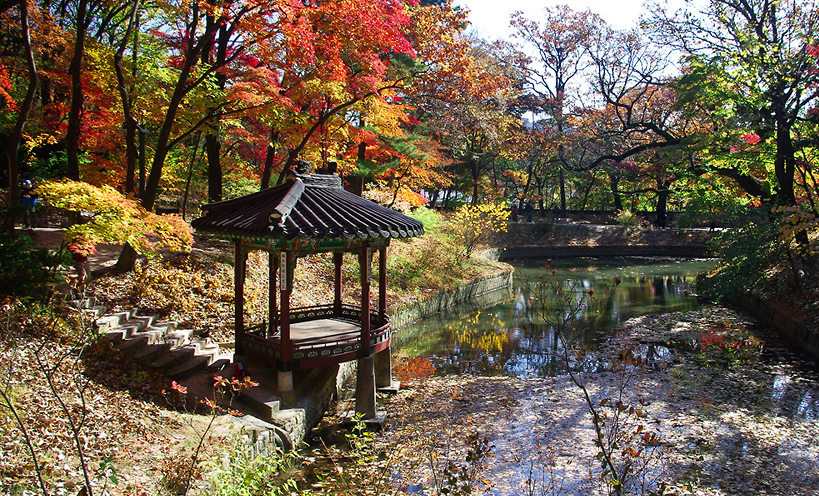

In [4]:
# 이미지의 높이와 넓이를 변수에 저장, 원본 이미지 출력

(height, width) = img.shape[:2]
print("width: {} pixels".format(width))      # 넓이
print("height: {} pixels".format(height))    # 높이
cv2_imshow(img)                              # 이미지 출력

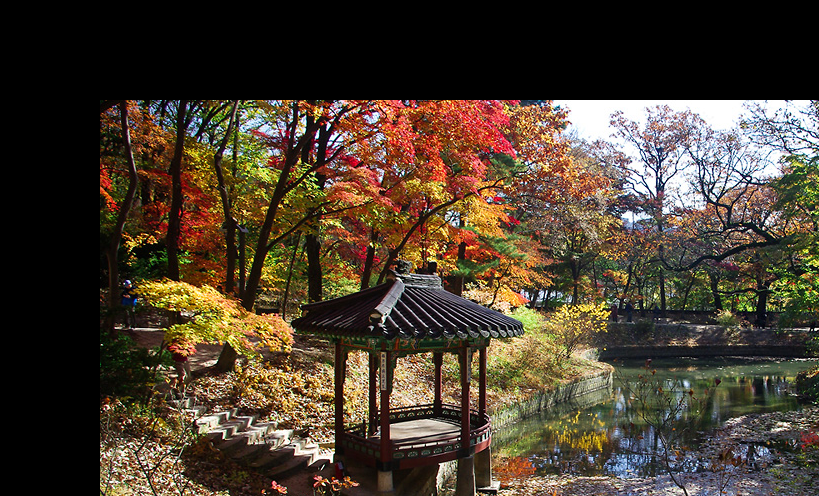

In [5]:
# 이미지를 이동시킵니다.("Moved right: +, left - and down: +, up: -")

# 어파인 변환 행렬 생성
move = np.float32([[1, 0, 100], [0, 1, 100]])       # [1, 0, 100] -> [좌/우, 크기],  [0, 1, 100] -> [위/아래, 크기]
moved = cv2.warpAffine(img, move, (width, height))  #  cv2.warpAffine() : 이미지를 이동시킨다.
cv2_imshow(moved)                                   # 이미지 출력

image center: {} pixels (409, 248)


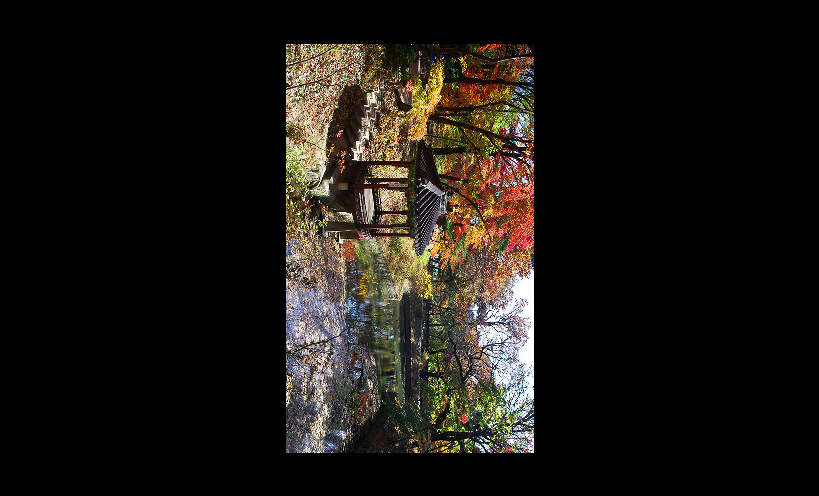

In [7]:
# OpenCV에서 제공하는 cv2.getRotationMatrix2D 함수를 이용하면 영상의 중앙을 기준점으로 회전할 수 있다.

# 이미지의 중심을 구합니다.
center = (width // 2, height // 2)
print("image center: {} pixels", center)               #  409, 248) - 이미지 중심 픽셀

# 이미지를 회전시킵니다.
rotate = cv2.getRotationMatrix2D(center, -90, 0.5)     # (센터, 각도(+:반시계, -:시계), 스케일(확대))
rotated = cv2.warpAffine(img, rotate, (width, height))

cv2_imshow(rotated)                                    # 회전된 이미지 출력

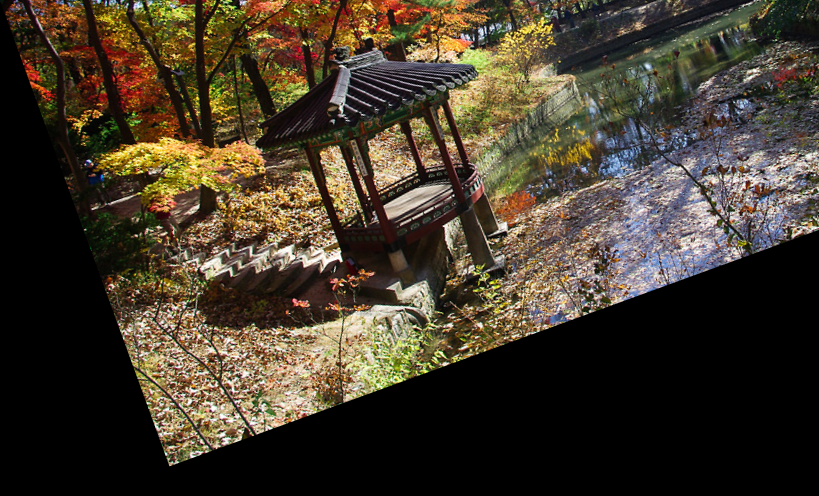

In [11]:
# 영상의 좌측 상단을 기준으로 반시계 방향으로 세타만큼 회전시킬 때 sin, cos 함수로 표현할 수 있다.
# np.array로 어파인 행렬을 생성하고, wrapAffine() 함수를 이용하여 회전한다.

import math

rad = 10 * math.pi / 90                        # 각도 설정

# np.array로 Affine 행렬 생성
aff = np.array([[math.cos(rad), math.sin(rad), 0], [-math.sin(rad), math.cos(rad), 0]], dtype=np.float32)
rotated2 = cv2.warpAffine(img, aff, (0, 0))    # (0,0) 의미는 입력영상 크기와 동일

cv2_imshow(rotated2)                           # 회전시킨 이미지 출력

ratio: 0.4884004884004884 pixels
dimension: (400, 242) pixels
resized: (242, 400, 3) pixels


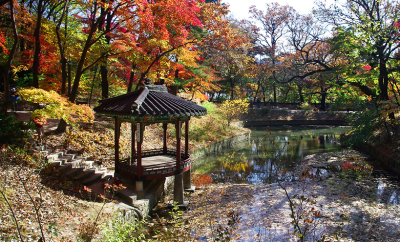

In [12]:
# 이미지 크기를 비율에 맞게 재조정 합니다.

ratio = 400.0 / width
dimension = (400, int(height * ratio))
print("ratio: {} pixels".format(ratio))               # ratio: 0.4884004884004884 pixels
print("dimension: {} pixels".format(dimension))       # dimension: (400, 242) pixels

# 축소된 넓이, 높이의 사이즈로 이미지를 재조정 한다.
resized = cv2.resize(img, dimension, interpolation = cv2.INTER_AREA)  # cv2.INTER_AREA - 영상 축소 시 효과적
print("resized: {} pixels".format(resized.shape))                     # resized: (242, 400, 3) pixels

cv2_imshow(resized)                                                   # 축소된 이미지 출력

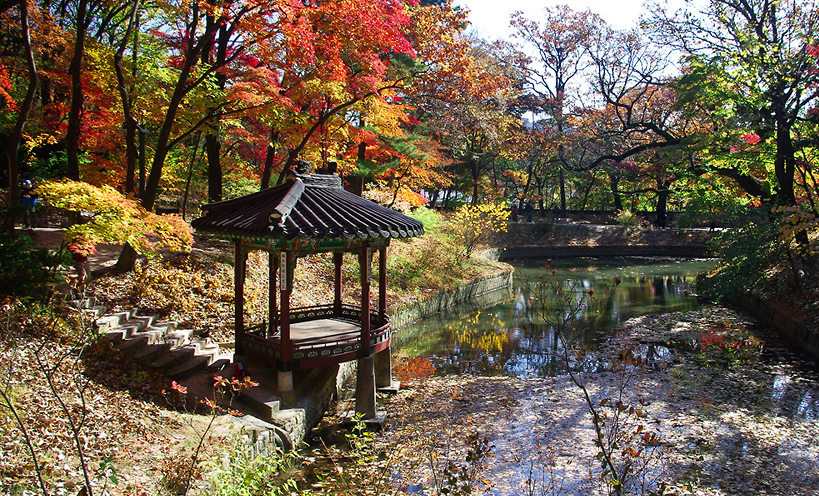

In [13]:
# 원본 이미지 출력
cv2_imshow(img)

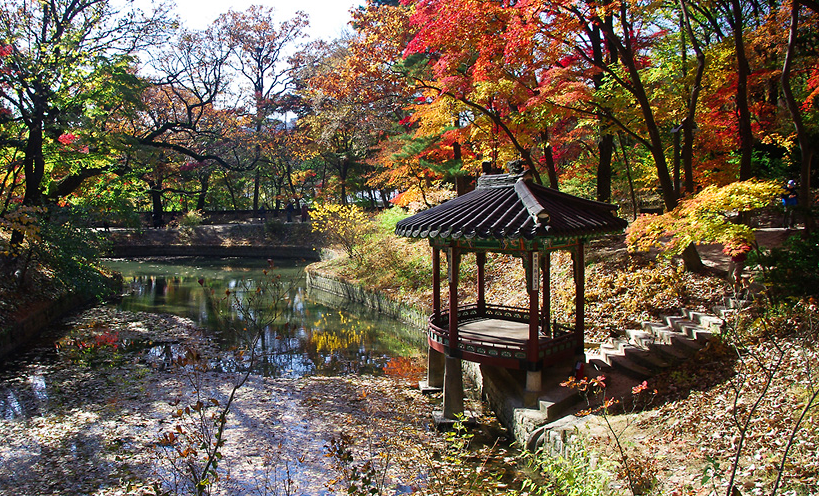

In [ ]:
#  cv2.flip(src, flipCode, dst=None)
#   - flipCode : 양수(+1) - 좌우 대칭, 0 - 상하 대칭, 음수(-1) - 좌우 & 상하 대칭

flipped = cv2.flip(img, 1)   # 1 : 좌우 대칭
cv2_imshow(flipped)          # 좌우 대칭 이미지 출력

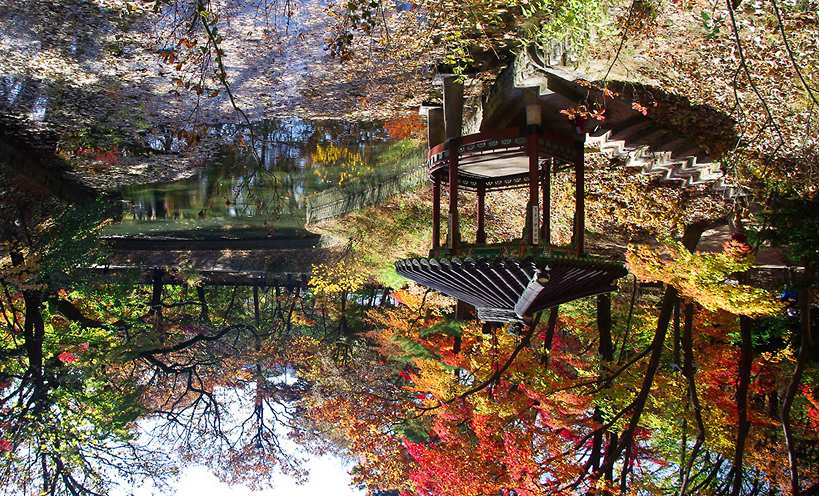

In [ ]:
#  cv2.flip(src, flipCode, dst=None)
#   - flipCode : 양수(+1) - 좌우 대칭, 0 - 상하 대칭, 음수(-1) - 좌우 & 상하 대칭

flipped = cv2.flip(img, -1)  # -1 : 좌우 & 상하 대칭
cv2_imshow(flipped)          # 좌우 & 상하 대칭 이미지 출력